CCS 249

Unit 5 Exercise

Luis Rafael L. Ajoc

BSCS 3A AI

In [94]:
import re
import math
import json
import random
from collections import Counter
from typing import List, Tuple, Dict
import matplotlib.pyplot as plt

import requests
from bs4 import BeautifulSoup
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import numpy as np

In [95]:
# Paste the Wikipedia link you want to use here. 
# The article should be reasonably long (at least a few thousand words) for good results.
WIKI_URL = "https://en.wikipedia.org/wiki/AKM"
RANDOM_SEED = 42

In [96]:
def ensure_nltk():
    resources = ["punkt", "punkt_tab"]
    for r in resources:
        try:
            nltk.data.find(f"tokenizers/{r}")
        except LookupError:
            nltk.download(r)

In [97]:
def fetch_wikipedia_article(url: str) -> str:
    headers = {
        "User-Agent": "Mozilla/5.0 (compatible; SGNS-AKM-Training/1.0)"
    }
    resp = requests.get(url, headers=headers, timeout=30)
    resp.raise_for_status()

    # Extract main content text from the Wikipedia page
    soup = BeautifulSoup(resp.text, "html.parser")

    content_div = soup.find("div", {"id": "mw-content-text"})
    if content_div is None:
        raise ValueError("Could not find Wikipedia article content.")

    paragraphs = content_div.find_all(["p", "li"])
    text_blocks = []

    for p in paragraphs:
        txt = p.get_text(" ", strip=True)
        if txt:
            text_blocks.append(txt)

    text = "\n".join(text_blocks)

    text = re.sub(r"\[[0-9]+\]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [98]:
def preprocess_text(text: str) -> List[List[str]]:
    sentences = sent_tokenize(text)

    processed = []
    for sent in sentences:
        sent = sent.lower()
        sent = re.sub(r"[^a-z0-9\-\s]", " ", sent)
        sent = re.sub(r"\s+", " ", sent).strip()
        if not sent:
            continue

        tokens = word_tokenize(sent)

        cleaned = []
        for tok in tokens:
            tok = tok.strip("-")
            if not tok:
                continue
            if tok.isdigit():
                continue
            if len(tok) < 2:
                continue
            cleaned.append(tok)

        if len(cleaned) >= 3:
            processed.append(cleaned)

    return processed

In [99]:
def corpus_stats(sentences: List[List[str]]) -> Dict[str, int]:
    flat = [w for s in sentences for w in s]
    vocab = set(flat)
    return {
        "num_sentences": len(sentences),
        "num_tokens": len(flat),
        "vocab_size": len(vocab),
    }

In [100]:
def train_sgns(sentences: List[List[str]]) -> Word2Vec:
    model = Word2Vec(
        sentences=sentences,
        vector_size=100, # What happens if we change this? Try 50, 200, 300 and see how it affects results.
        window=10,
        min_count=1,
        workers=4,
        sg=1,          # 0 = CBOW, 1 = skip-gram
        negative=10,   # negative sampling
        epochs=200,
        sample=1e-3,
        alpha=0.025,
        min_alpha=0.0007,
        seed=RANDOM_SEED,
    )
    return model

In [101]:
def has_word(model: Word2Vec, word: str) -> bool:
    return word in model.wv.key_to_index

In [102]:
def cosine(model: Word2Vec, w1: str, w2: str) -> float:
    v1 = model.wv[w1].reshape(1, -1)
    v2 = model.wv[w2].reshape(1, -1)
    return float(cosine_similarity(v1, v2)[0][0])

In [103]:
def evaluate_relatedness(model: Word2Vec, test_pairs: List[Tuple[str, str, float]]):
    gold = []
    pred = []
    covered = []

    for w1, w2, score in test_pairs:
        if has_word(model, w1) and has_word(model, w2):
            sim = cosine(model, w1, w2)
            gold.append(score)
            pred.append(sim)
            covered.append((w1, w2, score, sim))

    return {
        "covered_items": covered,
        "coverage": len(covered),
        "total": len(test_pairs),
    }

In [104]:
def evaluate_analogies(model: Word2Vec, analogies: List[Tuple[str, str, str, str]]):
    """
    Analogy format: a:b :: c:d
    Checks whether most_similar(positive=[b,c], negative=[a]) returns d.
    """
    covered = 0
    correct = 0
    details = []

    for a, b, c, d in analogies:
        if all(has_word(model, w) for w in [a, b, c, d]):
            covered += 1
            try:
                preds = model.wv.most_similar(positive=[b, c], negative=[a], topn=5)
                predicted_words = [w for w, _ in preds]
                hit = d in predicted_words
                correct += int(hit)
                details.append({
                    "analogy": f"{a}:{b}::{c}:?",
                    "expected": d,
                    "predictions": predicted_words,
                    "correct_in_top5": hit
                })
            except KeyError:
                pass

    accuracy = correct / covered if covered else float("nan")
    return {
        "coverage": covered,
        "total": len(analogies),
        "accuracy_top5": accuracy,
        "details": details
    }

In [105]:
def print_top_neighbors(model: Word2Vec, words: List[str], topn: int = 8):
    print("\n=== Nearest Neighbors ===")
    for word in words:
        if has_word(model, word):
            neighbors = model.wv.most_similar(word, topn=topn)
            print(f"\n{word}:")
            for neigh, score in neighbors:
                print(f"  {neigh:20s} {score:.4f}")
        else:
            print(f"\n{word}: [OOV]")

In [106]:
def apply_plot_pca(words, model):
    filtered_words = [w for w in words if w in model.wv]
    vectors = np.array([model.wv[w] for w in filtered_words])

    pca = PCA(n_components=2)
    reduced = pca.fit_transform(vectors)

    plt.figure(figsize=(10, 7))
    plt.scatter(reduced[:, 0], reduced[:, 1])

    for i, word in enumerate(filtered_words):
        plt.annotate(
            word,
            (reduced[i, 0], reduced[i, 1]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9
        )

    plt.title("PCA Visualization of AKM Word2Vec Embeddings")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(True)

    plt.show()

In [107]:
# Domain-specific relatedness test set
# Higher score means should be more semantically related
relatedness_test = [
    ("akm", "kalashnikov", 0.95),
    ("akm", "rifle", 0.95),
    ("akm", "weapon", 0.90),
    ("akm", "soviet", 0.85),
    ("rifle", "weapon", 0.90),
    ("cartridge", "7.62", 0.80),
    ("magazine", "round", 0.75),
    ("automatic", "fire", 0.85),
    ("gas", "piston", 0.85),
    ("bolt", "rotating", 0.80),

    # weak / unrelated pairs
    ("akm", "banana", 0.05),
    ("rifle", "kitchen", 0.02),
    ("magazine", "television", 0.10),
    ("soviet", "pizza", 0.01),
]

probe_words = [
    "akm", "kalashnikov", "rifle", "weapon",
    "soviet", "army", "cartridge", "magazine",
    "automatic", "gas", "bolt", "variant"
]

# Small analogy-style test set
# These are intentionally tiny and corpus-dependent because a single article is a small dataset.
# Change this based on what you find in the article and what words are present in the model.
analogy_test = [
    ("ak47", "akm", "akm", "variant"),
    ("rifle", "weapon", "pistol", "weapon"),
    ("automatic", "fire", "semi", "automatic"),
    ("soldier", "army", "pilot", "aircraft"),  # may fail but good test
]

# Change these pairs based on what you expect to be related/unrelated in the article and what words are in the model.
check_pairs = [
    ("akm", "rifle"),
    ("akm", "kalashnikov"),
    ("rifle", "weapon"),
    ("gas", "piston"),
    ("akm", "banana"),
]

# Words to visualize
words = [
    "akm", "ak47", "rifle", "weapon", "soviet",
    "variant", "cartridge", "magazine", "bolt", "gas",
    "system", "rotating", "mechanism", "soldiers", "military",
    "combat", "design", "kalashnikov", "production", "ammunition"
]

In [108]:
def main():
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    ensure_nltk()

    print("Downloading Wikipedia article...")
    raw_text = fetch_wikipedia_article(WIKI_URL)

    print("Preprocessing text...")
    sentences = preprocess_text(raw_text)
    stats = corpus_stats(sentences)

    print("\n=== Corpus Stats ===")
    for k, v in stats.items():
        print(f"{k}: {v}")

    print("\nTraining Skip-gram with Negative Sampling...")
    model = train_sgns(sentences)

    print("\nVocabulary size learned:", len(model.wv))

    print_top_neighbors(model, probe_words, topn=8)

    rel_results = evaluate_relatedness(model, relatedness_test)

    print("\n=== Relatedness Test Set ===")
    print(f"Coverage: {rel_results['coverage']}/{rel_results['total']}")
    for w1, w2, gold, pred in rel_results["covered_items"]:
        print(f"{w1:10s} - {w2:10s} | gold={gold:.2f} pred={pred:.4f}")

    analogy_results = evaluate_analogies(model, analogy_test)

    print("\n=== Analogy Test Set ===")
    print(f"Coverage: {analogy_results['coverage']}/{analogy_results['total']}")
    print(f"Top-5 accuracy: {analogy_results['accuracy_top5']}")
    for item in analogy_results["details"]:
        print(json.dumps(item, ensure_ascii=False))

    # Example direct similarity checks
    print("\n=== Direct Similarity Checks ===")
    
    for w1, w2 in check_pairs:
        if has_word(model, w1) and has_word(model, w2):
            print(f"{w1:10s} <-> {w2:10s}: {cosine(model, w1, w2):.4f}")
        else:
            print(f"{w1:10s} <-> {w2:10s}: OOV")

    # PCA
    apply_plot_pca(words=words, model=model)

    # Save model
    model.save("exercise_5_skipgram_sgns.model")
    print("\nSaved model to: exercise_5_skipgram_sgns.model")

    print("\nDone.")

Preprocessing text...

=== Corpus Stats ===
num_sentences: 434
num_tokens: 6177
vocab_size: 2030

Training Skip-gram with Negative Sampling...

Vocabulary size learned: 2030

=== Nearest Neighbors ===

akm:
  nato                 0.4302
  yonmarhanlan         0.4246
  rechambered          0.4245
  corps                0.4199
  batam                0.4192
  czech                0.4178
  iv                   0.4177
  45mm                 0.4174

kalashnikov:
  ak47                 0.7231
  evolution            0.7224
  story                0.7166
  receive              0.7125
  history              0.7002
  utl                  0.6901
  became               0.6883
  sell                 0.6854

rifle:
  fb                   0.6298
  hunter               0.6026
  tantal               0.5949
  short-barreled       0.5937
  mini-beryl           0.5924
  assault              0.5917
  petra                0.5907
  beryl                0.5842

weapon:
  brush                0.7307
  increase  

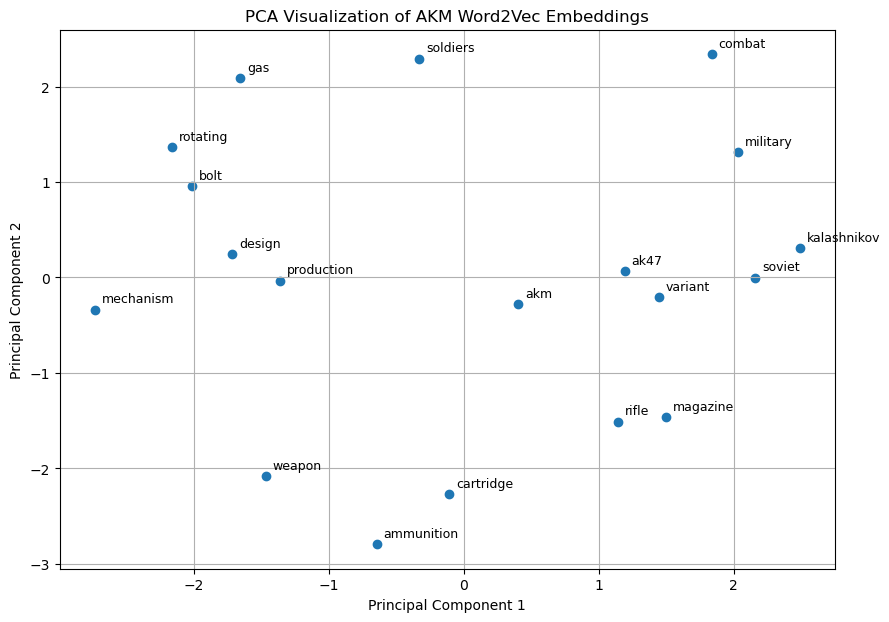


Saved model to: exercise_5_skipgram_sgns.model

Done.


In [109]:
main()